<div style="background:#005A67;padding:28px;border-radius:18px;color:white">
  <p style="margin:0;color:#F6BD38;font-weight:700;letter-spacing:1px">PROJETO INTEGRADOR · FUNDAMENTOS DE IA E PROGRAMAÇÃO</p>
  <h1 style="margin:8px 0 4px">Rota em Dia</h1>
  <h3 style="margin:0;font-weight:400">Por que os ônibus fretados estão chegando atrasados?</h3>
</div>

**Equipe:** Juliana Ballin Lima · Fernanda de Oliveira da Costa · Pedro Henrique Oliveira Dias  
**Período analisado:** fevereiro a maio de 2026 · **Escopo:** 8 rotas e 3 turnos

[Consultar o relatório técnico descritivo](https://github.com/JulianaBallin/TransitTrace/blob/main/docs/relatorio/relatorio_tecnico_rota_em_dia.pdf)

> **Pergunta central:** por que os atrasos aumentaram, onde se concentram e quais evidências sustentam a explicação mais plausível?

## Como executar no Google Colab

1. Faça upload deste notebook e do arquivo `projeto_integrador_transporte_fretado.csv` na mesma sessão.
2. Clique em **Ambiente de execução > Executar tudo**.
3. Se o CSV não for encontrado, a primeira célula solicitará o upload.

O notebook preserva a base bruta em `raw` e cria a base tratada em `data`. Nenhuma correção é feita silenciosamente.

In [1]:
from pathlib import Path
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

CREAM = "#FFF8E8"
TEAL = "#005A67"
MINT = "#65C3A5"
CORAL = "#F06449"
YELLOW = "#F6BD38"
INK = "#17343A"
GRAY = "#A7B0B3"

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": CREAM,
    "axes.facecolor": CREAM,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "grid.color": "#D8E0E0",
})

In [2]:
candidates = [
    Path("dataset/projeto_integrador_transporte_fretado.csv"),
    Path("projeto_integrador_transporte_fretado.csv"),
    Path("/content/projeto_integrador_transporte_fretado.csv"),
]
data_path = next((path for path in candidates if path.exists()), None)

if data_path is None:
    from google.colab import files
    uploaded = files.upload()
    csv_name = next(name for name in uploaded if name.endswith(".csv"))
    data_path = Path(csv_name)

raw = pd.read_csv(data_path)
print(f"Arquivo: {data_path}")
print(f"Dimensão: {raw.shape[0]} linhas × {raw.shape[1]} colunas")

Arquivo: dataset/projeto_integrador_transporte_fretado.csv
Dimensão: 2463 linhas × 11 colunas


## Roteiro da investigação

| Etapa | Pergunta | Produto |
|---|---|---|
| 1 · Primeiro diagnóstico | O que parece estar acontecendo? | Indicadores iniciais e hipóteses concorrentes |
| 2 · Estatística | Onde, quando e com que intensidade? | Comparações, variabilidade e hipóteses atualizadas |
| 3 · Limpeza | Podemos confiar nos dados? | Pipeline, validação e comparação antes × depois |
| 4 · EDA | Qual explicação é mais plausível? | Cinco visualizações, conclusão e recomendações |

**Regra de leitura:** evidência observada, interpretação, hipótese e limitação aparecem separadas ao longo do notebook.

# Etapa 1 · Primeiro diagnóstico

Nesta etapa a base é observada como foi recebida. Não corrigimos rótulos, duplicatas ou valores extremos.

In [3]:
preview = raw.head(6)
display(preview)

parsed_dates = pd.to_datetime(
    raw["data"], format="mixed", dayfirst=True, errors="coerce"
)
diagnosis = pd.DataFrame({
    "informação": ["Linhas", "Colunas", "Início", "Fim", "Dias de operação"],
    "valor": [
        len(raw),
        raw.shape[1],
        parsed_dates.min().strftime("%d/%m/%Y"),
        parsed_dates.max().strftime("%d/%m/%Y"),
        parsed_dates.nunique(),
    ],
})
display(diagnosis)
display(raw.dtypes.rename("tipo").to_frame())

,data,turno,rota,zona_origem,empresa,horario_previsto,horario_chegada,atraso_min,passageiros,chuva_mm,ocorrencia
0,2026-02-02,Manhã,R01,Norte,Viação Alfa,05:45,05:44,-1,33,0.0,Nenhuma
1,2026-02-02,manha,R02,Norte,Viação Alfa,05:45,05:43,-2,34,0.0,Nenhuma
2,2026-02-02,Manhã,R03,Leste,Viação Beta,05:45,05:36,-9,39,0.0,Nenhuma
3,2026-02-02,Manhã,R04,Sul,Viação Alfa,05:45,05:39,-6,120,0.0,Nenhuma
4,2026-02-02,Manhã,R05,Leste,Viação Beta,05:45,05:42,-3,35,0.0,Nenhuma
5,2026-02-02,Manhã,R06,Oeste,Viação Alfa,05:45,05:42,7,41,0.0,Nenhuma


,informação,valor
0,Linhas,2463
1,Colunas,11
2,Início,02/02/2026
3,Fim,30/05/2026
4,Dias de operação,102


,tipo
data,object
turno,object
rota,object
zona_origem,object
empresa,object
horario_previsto,object
horario_chegada,object
atraso_min,int64
passageiros,int64
chuva_mm,float64


### Indicador principal

Uma viagem é **pontual** quando chega no máximo 5 minutos após o horário previsto.

**Pontualidade (%) = viagens com atraso ≤ 5 min ÷ total de viagens × 100.**

O atraso acima de 15 minutos é analisado separadamente, pois o ônibus deveria chegar 15 minutos antes do início do turno.

In [4]:
raw_analysis = raw.assign(pontual=raw["atraso_min"].le(5))

overall_raw = pd.DataFrame({
    "indicador": ["Pontualidade", "Mediana do atraso", "Chegadas após o início do turno"],
    "resultado": [
        f"{raw_analysis['pontual'].mean() * 100:.1f}%",
        f"{raw_analysis['atraso_min'].median():.0f} min",
        f"{raw_analysis['atraso_min'].gt(15).sum()} viagens",
    ],
})
display(overall_raw)

def punctuality_table(frame, group):
    return (
        frame.groupby(group, dropna=False)["pontual"]
        .agg(viagens="size", pontualidade="mean")
        .assign(pontualidade=lambda table: table["pontualidade"] * 100)
        .sort_values("pontualidade")
        .round(1)
    )

display(punctuality_table(raw_analysis, "rota").head(12))
display(punctuality_table(raw_analysis, "turno"))

,indicador,resultado
0,Pontualidade,81.4%
1,Mediana do atraso,-1 min
2,Chegadas após o início do turno,125 viagens


,viagens,pontualidade
rota,,
Rota 05,2,0.0
R3,2,50.0
Rota 08,2,50.0
r05,6,50.0
R05,300,64.7
R1,3,66.7
R5,3,66.7
R03,299,67.6
r04,4,75.0


,viagens,pontualidade
turno,,
tarde,20,65.0
Manhã,805,76.1
Tarde,801,77.9
MANHÃ,10,80.0
noite,6,83.3
Noite,808,90.2
Noturno,7,100.0
manha,6,100.0


### O que chama atenção antes da limpeza

- R03 e R05 aparecem entre as rotas menos pontuais, mesmo com rótulos fragmentados.
- Manhã e tarde parecem piores que o turno noturno.
- A média do atraso é maior que a mediana, sinal de assimetria e valores extremos.
- Há grafias diferentes para a mesma rota e o mesmo turno, além de chuva ausente e lotação acima de 44 lugares.

### Hipóteses concorrentes iniciais

| Hipótese | Evidência inicial | O que ainda precisamos verificar |
|---|---|---|
| H1 · Chuva | O período é chuvoso e há viagens com chuva forte | Se o efeito ocorre em todas as rotas e datas |
| H2 · Corredor R03/R05 | As duas rotas têm menor pontualidade | Quando a piora começa e se o turno noturno também muda |
| H3 · Ocorrências pontuais | Pane, trânsito, pneu e obra aparecem na base | Se casos isolados explicam a mudança sustentada |

**Pergunta investigativa:** a queda de pontualidade é geral por causa da chuva ou está concentrada em rotas, turnos e período específicos?

# Etapa 2 · Estatística descritiva

Comparamos tendência central, variabilidade, quartis, outliers, rotas, turnos, zonas, empresas e evolução temporal. A base ainda não foi corrigida, portanto as conclusões permanecem provisórias.

In [5]:
raw_stats = raw["atraso_min"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]
).rename({
    "count": "n", "mean": "média", "std": "desvio padrão",
    "min": "mínimo", "25%": "Q1", "50%": "mediana",
    "75%": "Q3", "95%": "P95", "99%": "P99", "max": "máximo",
})
display(raw_stats.round(2).to_frame("atraso_min"))

q1, q3 = raw["atraso_min"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
print(f"IQR: {iqr:.1f} min | limite superior: {upper_limit:.1f} min")
print(f"Possíveis outliers pelo IQR: {raw['atraso_min'].gt(upper_limit).sum()}")

,atraso_min
n,2463.00
média,2.51
desvio padrão,36.44
mínimo,-13.00
Q1,-4.00
mediana,-1.00
Q3,3.00
P95,16.00
P99,34.38
máximo,739.00


IQR: 7.0 min | limite superior: 13.5 min
Possíveis outliers pelo IQR: 172


In [6]:
canonical_rows = raw[
    raw["rota"].astype(str).str.fullmatch(r"R\d{2}")
    & raw["turno"].isin(["Manhã", "Tarde", "Noite"])
].copy()
canonical_rows["data_aux"] = pd.to_datetime(
    canonical_rows["data"], format="mixed", dayfirst=True, errors="coerce"
)
canonical_rows["pontual"] = canonical_rows["atraso_min"].le(5)

route_stats_raw = canonical_rows.groupby("rota").agg(
    viagens=("atraso_min", "size"),
    pontualidade=("pontual", "mean"),
    média=("atraso_min", "mean"),
    mediana=("atraso_min", "median"),
    desvio=("atraso_min", "std"),
)
route_stats_raw["pontualidade"] *= 100
display(route_stats_raw.round(1))

monthly_raw = canonical_rows.pivot_table(
    index="rota",
    columns=canonical_rows["data_aux"].dt.strftime("%Y-%m"),
    values="pontual",
    aggfunc="mean",
).mul(100)
display(monthly_raw.round(1))

,viagens,pontualidade,média,mediana,desvio
rota,,,,,
R01,291,87.3,0.1,-2.0,7.2
R02,289,84.1,2.5,-1.0,42.8
R03,292,67.1,3.8,1.0,9.9
R04,292,86.6,4.7,-2.0,59.8
R05,289,65.1,6.1,1.0,44.3
R06,299,88.3,-0.5,-2.0,6.6
R07,296,87.2,1.7,-2.0,42.6
R08,293,85.3,2.5,-2.0,42.5


data_aux,2026-02,2026-03,2026-04,2026-05
rota,,,,
R01,91.0,81.3,87.7,89.5
R02,88.1,73.6,89.5,85.1
R03,92.8,77.3,52.6,47.2
R04,94.0,79.2,79.2,94.7
R05,93.9,76.3,54.1,38.4
R06,91.5,81.8,85.9,94.5
R07,94.0,74.7,85.1,96.1
R08,88.1,81.8,80.8,90.8


### Leitura provisória das hipóteses

| Hipótese | Evidência a favor | Evidência contra ou limitação | Situação |
|---|---|---|---|
| H1 · Chuva | Atrasos crescem em dias mais chuvosos | Não explica por que duas rotas pioram muito mais | Aberta |
| H2 · Corredor R03/R05 | A piora mensal se concentra em R03 e R05 | A base ainda tem categorias e extremos inválidos | Ganhou força |
| H3 · Ocorrências pontuais | Pane produz atrasos severos | Casos esparsos não formam sozinhos uma ruptura | Perdeu força |

A média bruta não é confiável neste momento: valores acima de 700 minutos elevam o desvio padrão. A mediana é mais robusta, mas a origem desses extremos precisa ser auditada.

# Etapa 3 · Limpeza e validação

O pipeline segue quatro princípios: preservar a base bruta, declarar critérios, investigar antes de remover e não imputar informação desconhecida sem justificativa.

**Regras adotadas:**

- datas aceitam os formatos observados e são convertidas com dia primeiro;
- horários com `h` ou segundos são padronizados para `HH:MM`;
- rotas são reconstruídas pelo número e turnos recebem um mapa de equivalências;
- atraso é recalculado pelos horários, pois 12 linhas divergem do valor informado;
- atrasos fora de -60 a 120 minutos e passageiros fora de 0 a 44 viram ausentes, sem apagar a viagem;
- chuva ausente permanece ausente e não entra no gráfico chuva × atraso;
- duplicatas são removidas apenas quando todos os campos são iguais.

In [7]:
def clean_transport_data(raw_frame):
    data = raw_frame.copy()
    duplicate_mask = raw_frame.duplicated(keep="first")

    data["data"] = pd.to_datetime(
        data["data"], format="mixed", dayfirst=True, errors="coerce"
    )
    data["turno"] = (
        data["turno"].astype("string").str.strip().str.casefold()
        .replace({"manha": "manhã", "noturno": "noite"}).str.title()
    )
    route_number = data["rota"].astype("string").str.extract(r"(\d+)", expand=False)
    data["rota"] = route_number.astype("Int64").map(
        lambda value: f"R{value:02d}" if pd.notna(value) else pd.NA
    )

    for column in ["zona_origem", "empresa", "ocorrencia"]:
        data[column] = data[column].astype("string").str.strip()
    for column in ["horario_previsto", "horario_chegada"]:
        data[column] = (
            data[column].astype("string").str.strip()
            .str.replace("h", ":", regex=False).str.slice(0, 5)
        )

    data = data.loc[~duplicate_mask].copy()
    scheduled = pd.to_datetime(
        data["data"].dt.strftime("%Y-%m-%d") + " " + data["horario_previsto"],
        errors="coerce",
    )
    arrived = pd.to_datetime(
        data["data"].dt.strftime("%Y-%m-%d") + " " + data["horario_chegada"],
        errors="coerce",
    )
    data["atraso_informado"] = data["atraso_min"]
    data["atraso_calculado"] = (arrived - scheduled).dt.total_seconds() / 60

    divergent = ~np.isclose(
        data["atraso_informado"], data["atraso_calculado"], equal_nan=True
    )
    invalid_delay = ~data["atraso_calculado"].between(-60, 120)
    invalid_capacity = ~data["passageiros"].between(0, 44)

    data["atraso_min"] = data["atraso_calculado"].mask(invalid_delay)
    data["passageiros"] = data["passageiros"].mask(invalid_capacity)
    data["pontual"] = data["atraso_min"].le(5).where(data["atraso_min"].notna())
    data["apos_inicio_turno"] = (
        data["atraso_min"].gt(15).where(data["atraso_min"].notna())
    )
    data["mes"] = data["data"].dt.to_period("M").astype("string")
    data["semana"] = data["data"].dt.to_period("W-SUN").apply(
        lambda period: period.start_time
    )
    data["periodo_ruptura"] = np.where(
        data["data"] < pd.Timestamp("2026-04-06"),
        "Antes de 06/04", "Desde 06/04"
    )
    data["grupo_rotas"] = np.where(
        data["rota"].isin(["R03", "R05"]), "R03 e R05", "Demais rotas"
    )

    log = pd.DataFrame([
        ["Categorias inconsistentes", "30 rotas e 8 turnos escritos", "Padronizar", "8 rotas e 3 turnos"],
        ["Valores ausentes", f"{raw_frame['chuva_mm'].isna().sum()} chuvas ausentes", "Manter NA", "Sem imputação"],
        ["Duplicados", f"{duplicate_mask.sum()} linhas idênticas", "Remover cópias", f"{len(raw_frame)} → {len(data)}"],
        ["Atraso divergente", f"{divergent.sum()} linhas", "Recalcular horários", "Indicador coerente"],
        ["Valores inválidos", f"{invalid_delay.sum()} atrasos; {invalid_capacity.sum()} lotações", "Marcar NA", "Viagens preservadas"],
    ], columns=["Problema", "Evidência", "Tratamento", "Impacto"])
    return data, log

data, cleaning_log = clean_transport_data(raw)
display(cleaning_log)

,Problema,Evidência,Tratamento,Impacto
0,Categorias inconsistentes,30 rotas e 8 turnos escritos,Padronizar,8 rotas e 3 turnos
1,Valores ausentes,145 chuvas ausentes,Manter NA,Sem imputação
2,Duplicados,15 linhas idênticas,Remover cópias,2463 → 2448
3,Atraso divergente,12 linhas,Recalcular horários,Indicador coerente
4,Valores inválidos,6 atrasos; 5 lotações,Marcar NA,Viagens preservadas


In [8]:
comparison = pd.DataFrame({
    "indicador": ["Registros", "Rotas distintas", "Turnos distintos", "Atraso médio", "Pontualidade"],
    "antes": [
        len(raw), raw["rota"].nunique(), raw["turno"].nunique(),
        f"{raw['atraso_min'].mean():.2f} min", f"{raw['atraso_min'].le(5).mean() * 100:.1f}%"
    ],
    "depois": [
        len(data), data["rota"].nunique(), data["turno"].nunique(),
        f"{data['atraso_min'].mean():.2f} min", f"{data['pontual'].mean() * 100:.1f}%"
    ],
})
display(comparison)

checks = pd.Series({
    "datas inválidas": int(data["data"].isna().sum()),
    "chaves data × turno × rota duplicadas": int(data.duplicated(["data", "turno", "rota"]).sum()),
    "rotas fora de R01 a R08": int((~data["rota"].isin([f"R{i:02d}" for i in range(1, 9)])).sum()),
    "turnos fora do domínio": int((~data["turno"].isin(["Manhã", "Tarde", "Noite"])).sum()),
    "lotações válidas acima de 44": int(data["passageiros"].gt(44).sum()),
}, name="quantidade")
display(checks.to_frame())

,indicador,antes,depois
0,Registros,2463,2448
1,Rotas distintas,30,8
2,Turnos distintos,8,3
3,Atraso médio,2.51 min,0.70 min
4,Pontualidade,81.4%,81.9%


,quantidade
datas inválidas,0
chaves data × turno × rota duplicadas,0
rotas fora de R01 a R08,0
turnos fora do domínio,0
lotações válidas acima de 44,0


### O que mudou após a limpeza

A média cai porque seis valores fisicamente implausíveis deixam de distorcê-la. A mediana, a queda temporal e a concentração em R03/R05 permanecem. Portanto, a hipótese principal **sobrevive à limpeza**.

| Hipótese | Antes | Depois | Situação |
|---|---|---|---|
| H1 · Chuva | Associação aparente | Associação permanece, mas é geral | Mantida como fator agravante |
| H2 · Corredor R03/R05 | Piora concentrada | Padrão fica mais nítido e começa em 06/04 | Ganhou força |
| H3 · Ocorrências pontuais | Extremos severos | Explicam casos, não a ruptura inteira | Perdeu força |

# Etapa 4 · EDA e visualização

Cada gráfico responde uma pergunta. Depois de cada figura registramos evidência, interpretação, hipótese e limitação.

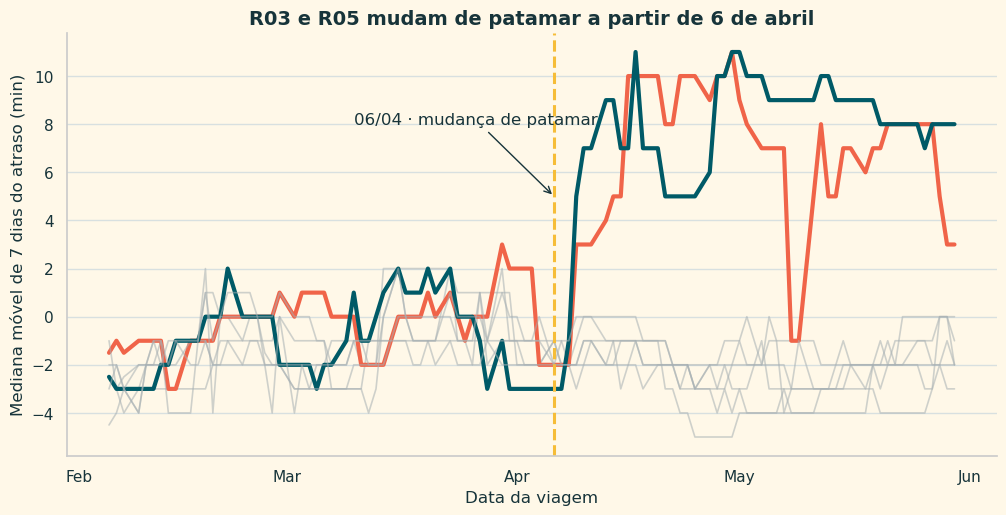

In [9]:
daily = (
    data.groupby(["data", "rota"])["atraso_min"].median().unstack()
    .rolling(7, min_periods=4).median()
)
fig, ax = plt.subplots(figsize=(12, 5.5))
for route in daily.columns:
    color, width, alpha = GRAY, 1.2, 0.55
    if route == "R03": color, width, alpha = CORAL, 3.0, 1
    if route == "R05": color, width, alpha = TEAL, 3.0, 1
    ax.plot(daily.index, daily[route], color=color, lw=width, alpha=alpha)
ax.axvline(pd.Timestamp("2026-04-06"), color=YELLOW, lw=2.2, ls="--")
ax.annotate("06/04 · mudança de patamar", xy=(pd.Timestamp("2026-04-06"), 5),
            xytext=(pd.Timestamp("2026-03-10"), 8),
            arrowprops={"arrowstyle": "->", "color": INK})
ax.set(title="R03 e R05 mudam de patamar a partir de 6 de abril",
       xlabel="Data da viagem", ylabel="Mediana móvel de 7 dias do atraso (min)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(axis="x", visible=False)
sns.despine()
plt.show()

**Evidência:** até o início de abril, as oito rotas oscilam perto de zero; depois de 06/04, R03 e R05 ficam entre 7 e 15 minutos.  
**Interpretação:** houve uma ruptura localizada, não uma piora gradual de toda a operação.  
**Hipótese:** as duas rotas passaram a enfrentar uma restrição compartilhada no corredor.  
**Limitação:** a linha marca uma mudança observada, não prova qual evento a causou.

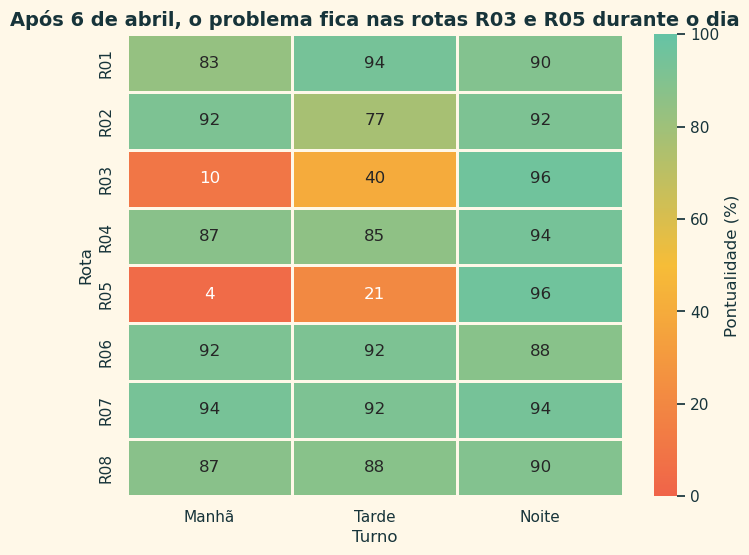

In [10]:
after_change = data[data["data"] >= "2026-04-06"]
heatmap = (
    after_change.pivot_table(index="rota", columns="turno", values="pontual", aggfunc="mean")
    .reindex(columns=["Manhã", "Tarde", "Noite"]).mul(100).astype(float)
)
cmap = sns.blend_palette([CORAL, YELLOW, MINT], as_cmap=True)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(heatmap, annot=True, fmt=".0f", vmin=0, vmax=100, cmap=cmap,
            linewidths=2, linecolor=CREAM, cbar_kws={"label": "Pontualidade (%)"}, ax=ax)
ax.set(title="Após 6 de abril, o problema fica nas rotas R03 e R05 durante o dia",
       xlabel="Turno", ylabel="Rota")
plt.show()

**Evidência:** a pontualidade cai para 10% e 40% em R03, e para 4% e 21% em R05, na manhã e tarde; à noite permanece em 96%.  
**Interpretação:** turno e rota interagem. O problema não é da rota durante as 24 horas.  
**Hipótese:** uma condição diurna no corredor compartilhado é compatível com o padrão.  
**Limitação:** não temos percurso GPS, duração por trecho nem horário de vigência da obra.

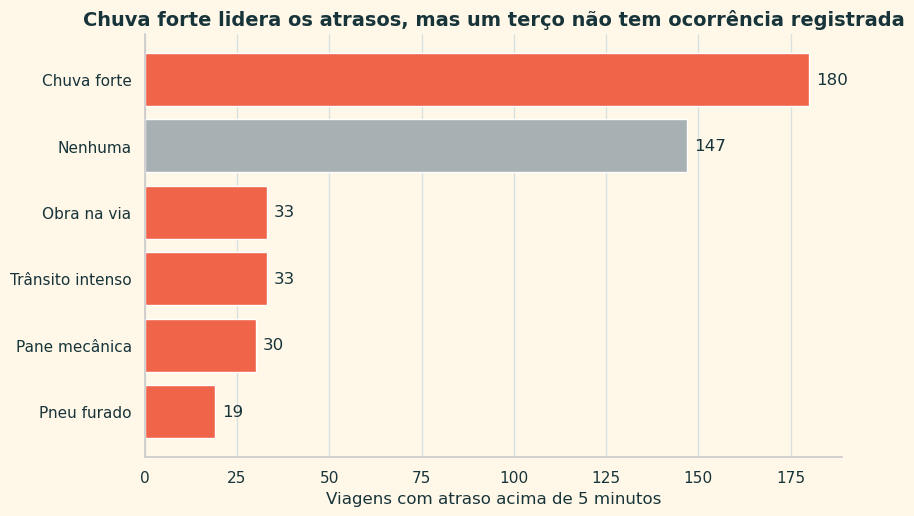

In [11]:
late = data[data["pontual"].eq(False)]
occurrences = late["ocorrencia"].value_counts().sort_values()
bar_colors = [GRAY if label == "Nenhuma" else CORAL for label in occurrences.index]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(occurrences.index, occurrences.values, color=bar_colors)
ax.bar_label(bars, padding=5)
ax.set(title="Chuva forte lidera os atrasos, mas um terço não tem ocorrência registrada",
       xlabel="Viagens com atraso acima de 5 minutos", ylabel="")
ax.grid(axis="y", visible=False)
sns.despine()
plt.show()

**Evidência:** chuva forte aparece em 180 viagens atrasadas; 147 atrasos não têm ocorrência registrada. Pane mecânica tem mediana mais alta, mas apenas 30 registros.  
**Interpretação:** chuva é frequente e pane é severa; nenhum dos dois, isoladamente, explica a concentração temporal e geográfica.  
**Hipótese:** ocorrências pontuais agravam o resultado, enquanto a ruptura tem componente estrutural.  
**Limitação:** o campo depende do registro do motorista e pode sofrer subnotificação.

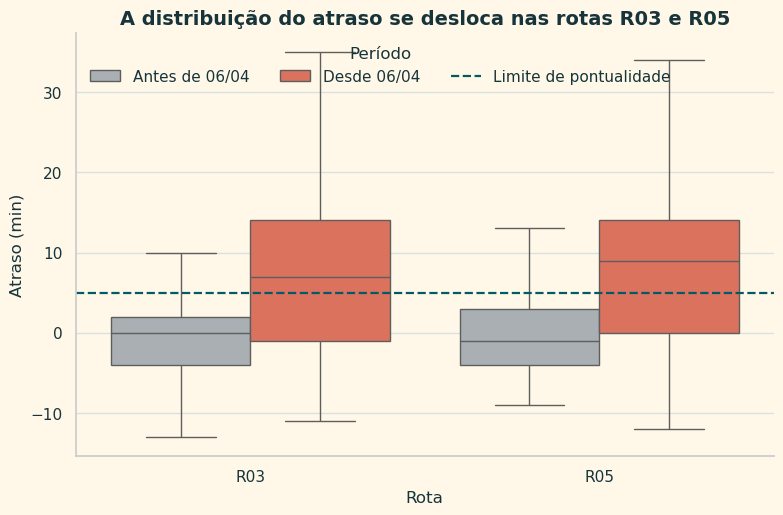

In [12]:
box_data = data[data["rota"].isin(["R03", "R05"])]
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.boxplot(data=box_data, x="rota", y="atraso_min", hue="periodo_ruptura",
            hue_order=["Antes de 06/04", "Desde 06/04"],
            palette=[GRAY, CORAL], showfliers=False, ax=ax)
ax.axhline(5, color=TEAL, ls="--", lw=1.6, label="Limite de pontualidade")
ax.set(title="A distribuição do atraso se desloca nas rotas R03 e R05",
       xlabel="Rota", ylabel="Atraso (min)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Período", frameon=False, ncol=3, loc="upper left")
sns.despine()
plt.show()

**Evidência:** a mediana das duas rotas passa de valores próximos de zero para patamares acima do limite de pontualidade.  
**Interpretação:** não é apenas um pequeno conjunto de extremos; a distribuição inteira se desloca.  
**Hipótese:** a operação cotidiana das duas rotas mudou após 06/04.  
**Limitação:** o boxplot agrega manhã, tarde e noite; o heatmap anterior é necessário para localizar o turno.

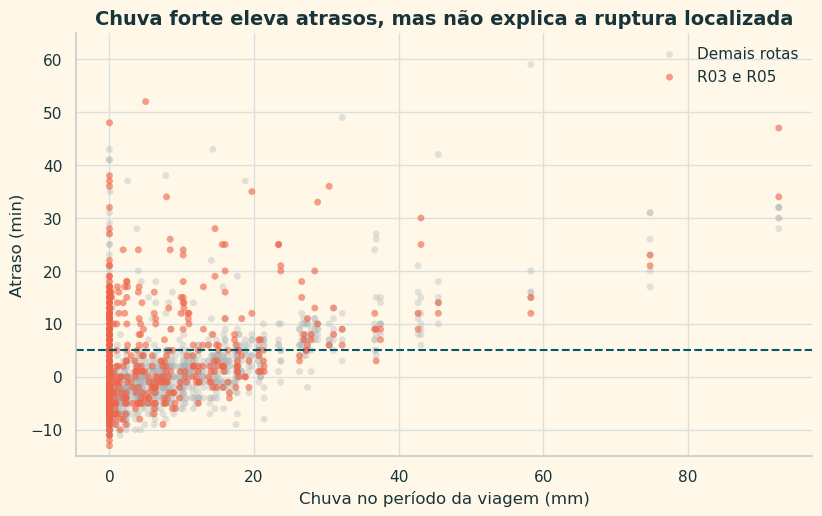

Correlação de Spearman entre chuva e atraso: 0.46


In [13]:
rain = data.dropna(subset=["chuva_mm", "atraso_min"])
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for group, color, alpha in [("Demais rotas", GRAY, 0.32), ("R03 e R05", CORAL, 0.62)]:
    subset = rain[rain["grupo_rotas"].eq(group)]
    ax.scatter(subset["chuva_mm"], subset["atraso_min"], s=25, alpha=alpha,
               color=color, label=group, edgecolors="none")
ax.axhline(5, color=TEAL, ls="--", lw=1.5)
ax.set(title="Chuva forte eleva atrasos, mas não explica a ruptura localizada",
       xlabel="Chuva no período da viagem (mm)", ylabel="Atraso (min)", ylim=(-15, 65))
ax.legend(frameon=False)
sns.despine()
plt.show()

correlation = rain[["chuva_mm", "atraso_min"]].corr(method="spearman").iloc[0, 1]
print(f"Correlação de Spearman entre chuva e atraso: {correlation:.2f}")

**Evidência:** há associação moderada entre chuva e atraso (Spearman ≈ 0,46), principalmente acima de 25 mm. Mesmo com pouca chuva, R03/R05 mantêm atrasos após 06/04.  
**Interpretação:** chuva funciona como fator agravante geral, não como explicação suficiente da ruptura.  
**Hipótese:** a restrição do corredor e a chuva podem se somar.  
**Limitação:** correlação não mede causalidade e chuva é medida no período, não ao longo de cada trajeto.

## Síntese numérica

Agora comparamos o grupo crítico com as demais rotas no mesmo período e nos mesmos turnos.

In [14]:
daytime_after = data[
    (data["data"] >= "2026-04-06")
    & data["turno"].isin(["Manhã", "Tarde"])
]
summary = daytime_after.groupby("grupo_rotas").agg(
    viagens=("atraso_min", "count"),
    pontualidade=("pontual", "mean"),
    mediana_atraso=("atraso_min", "median"),
    após_turno=("apos_inicio_turno", "sum"),
)
summary["pontualidade"] *= 100
display(summary.round(1))

roadwork = data[data["ocorrencia"].eq("Obra na via")]
print("Obra na via por rota:")
display(roadwork.groupby("rota").agg(
    registros=("data", "size"), início=("data", "min"), fim=("data", "max")
))

,viagens,pontualidade,mediana_atraso,após_turno
grupo_rotas,,,,
Demais rotas,573,88.481675,-2.0,14
R03 e R05,191,18.848168,12.0,53


Obra na via por rota:


,registros,início,fim
rota,,,
R03,19,2026-04-07,2026-05-28
R05,20,2026-04-08,2026-05-30


## Quadro final das hipóteses

| Hipótese | Evidência a favor | Evidência contra ou limitação | Decisão |
|---|---|---|---|
| H1 · Chuva explica a piora | Associação moderada; 180 atrasos com chuva forte | Afeta todas as rotas e não coincide com a ruptura localizada | **Inconclusiva como causa principal; mantida como agravante** |
| H2 · Restrição no corredor R03/R05 | Ruptura em 06/04, somente diurna; “Obra na via” surge em 07/04 apenas nessas rotas | Falta cronograma da obra e GPS por trecho | **Mantida como explicação mais plausível** |
| H3 · Falhas isoladas explicam a piora | Pane e pneu geram atrasos severos | Poucos casos e dispersos; distribuição inteira muda | **Rejeitada como explicação principal** |

O fato de R07 e R08, também operadas pela Viação Beta, permanecerem estáveis enfraquece uma explicação baseada apenas na empresa.

# Preparação da narrativa

## Mensagem central · 28 palavras

> **A pontualidade de R03 e R05 caiu nos turnos diurnos desde 6 de abril; obras no corredor são a explicação mais plausível, a confirmar com GPS e cronogramas.**

## Storyboard em três atos

| Ato | O que contar | O que mostrar |
|---|---|---|
| 1 · Problema | A pontualidade geral esconde uma ruptura localizada | Série temporal com marca em 06/04 |
| 2 · Investigação | Chuva agrava, mas não separa as rotas; limpeza remove distorções | Dispersão, heatmap e antes × depois |
| 3 · Resolução | Corredor compartilhado é a hipótese mais plausível; falta confirmação operacional | Gráfico explicativo e três ações |

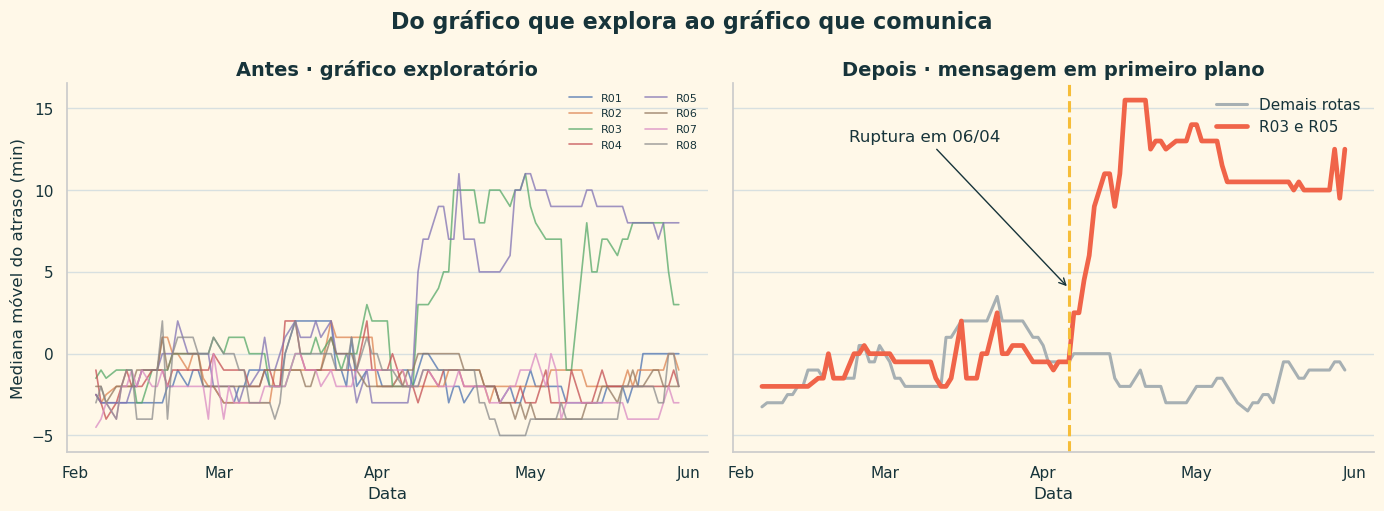

In [15]:
daytime = data[data["turno"].isin(["Manhã", "Tarde"])]
grouped = (
    daytime.groupby(["data", "grupo_rotas"])["atraso_min"].median().unstack()
    .rolling(7, min_periods=4).median()
)

fig, (left, right) = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
for route in daily.columns:
    left.plot(daily.index, daily[route], lw=1.2, alpha=0.75, label=route)
left.set(title="Antes · gráfico exploratório", xlabel="Data",
         ylabel="Mediana móvel do atraso (min)")
left.legend(ncol=2, frameon=False, fontsize=8)

right.plot(grouped.index, grouped["Demais rotas"], color=GRAY, lw=2.2, label="Demais rotas")
right.plot(grouped.index, grouped["R03 e R05"], color=CORAL, lw=3.4, label="R03 e R05")
right.axvline(pd.Timestamp("2026-04-06"), color=YELLOW, lw=2.2, ls="--")
right.annotate("Ruptura em 06/04", xy=(pd.Timestamp("2026-04-06"), 4),
               xytext=(pd.Timestamp("2026-02-22"), 13),
               arrowprops={"arrowstyle": "->", "color": INK})
right.set(title="Depois · mensagem em primeiro plano", xlabel="Data")
right.legend(frameon=False)

for axis in (left, right):
    axis.xaxis.set_major_locator(mdates.MonthLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    axis.grid(axis="x", visible=False)
    sns.despine(ax=axis)
plt.suptitle("Do gráfico que explora ao gráfico que comunica", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Conclusão e recomendações

1. **O que aconteceu?** A pontualidade geral ficou em 81,9%, mas a média esconde uma mudança brusca nas rotas R03 e R05.
2. **Onde aconteceu?** Nos turnos da manhã e da tarde das duas rotas, ambas da zona Leste. O turno noturno permaneceu estável.
3. **Quando começou?** Em 6 de abril de 2026. O primeiro registro de “Obra na via” aparece em 7 de abril.
4. **Quais evidências sustentam a explicação?** Série temporal, heatmap rota × turno, deslocamento das distribuições e registros de obra somente em R03/R05.
5. **Qual explicação é mais plausível?** Interferência diurna no corredor compartilhado, compatível com obra na via. Chuva agrava o atraso, mas não explica a concentração.
6. **O que ainda não pode ser afirmado?** Os dados não provam causalidade nem identificam o trecho exato.

### Próximas ações

- cruzar o período com cronograma e localização das obras públicas;
- coletar GPS e tempo por trecho de R03/R05 por duas semanas;
- testar desvio de rota ou antecipação de 15 minutos nos turnos diurnos, acompanhando pontualidade e tempo total.

### Pontos de aprendizado

- a média geral pode esconder um problema localizado;
- limpeza reproduzível muda números, mas uma conclusão robusta deve sobreviver a ela;
- mediana e distribuição são essenciais quando há extremos;
- associação visual não equivale a causalidade;
- um gráfico explicativo exige seleção, contraste e anotação.

In [16]:
output_columns = [
    "data", "turno", "rota", "zona_origem", "empresa",
    "horario_previsto", "horario_chegada", "atraso_min",
    "passageiros", "chuva_mm", "ocorrencia", "pontual",
    "apos_inicio_turno",
]
treated_path = (
    Path("dataset/dados_tratados_transporte_fretado.csv")
    if Path("dataset").is_dir()
    else Path("dados_tratados_transporte_fretado.csv")
)
data[output_columns].to_csv(treated_path, index=False, date_format="%Y-%m-%d")
print(f"Base tratada salva em: {treated_path.resolve()}")

Base tratada salva em: /home/cronos-1226/Documentos/SiaLabs/cursos-denken/fundamentos-de-ia/entrega-final/TransitTrace/dataset/dados_tratados_transporte_fretado.csv
